# Setup

In [9]:
# Base imports
import os
import pickle

# Compute imports
import numpy as np
import pandas as pd
import scipy
from tqdm.notebook import tqdm, trange

# Plotting imports
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
from matplotlib import pyplot as plt
import seaborn as sns
from plotly import express as px

# ML import
from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error, median_absolute_error
from sklearn.metrics.pairwise import cosine_similarity
from pyphylon.util import load_config



In [10]:
CONFIG = load_config("config.yml")
SPECIES = CONFIG["PG_NAME"]
temp_folder = CONFIG.get("REUSE_TEMP_DIR", "../temp/")
data_dir = CONFIG.get("SNAKEMAKE_DATA_DIR", "data/")

In [11]:
# Load in (full) P matrix
df_genes = pd.read_pickle(os.path.join(data_dir, f'processed/cd-hit-results/{SPECIES}_strain_by_gene.pickle.gz'))

# Load in metadata
ENRICHED_METADATA = os.path.join(temp_folder, '2d_enriched_metadata.csv')
# Load in (full) metadata
metadata = pd.read_csv(ENRICHED_METADATA, index_col=0, dtype='object')
metadata = metadata[metadata['genome_id'].isin(df_genes.columns)]

# Filter metadata for Complete sequences only
metadata = metadata[metadata.genome_status == 'Complete'] # filter for only Complete sequences

# Filter P matrix for Complete sequences only
df_genes_complete = df_genes[metadata.genome_id].copy()
df_genes_complete.fillna(0, inplace=True) # replace N/A with 0
df_genes_complete = df_genes_complete.sparse.to_dense().astype('int8') # densify & typecast to int8 for space and compute reasons
inCompleteseqs = df_genes_complete.sum(axis=1) > 0 # filter for genes found in complete sequences
df_genes_complete = df_genes_complete[inCompleteseqs]

df_genes_complete.shape

(8318, 355)

In [12]:
# # Load in eggNOG annotations
# df_eggnog = pd.read_csv('df_eggnog.csv', index_col=0)
# df_eggnog.fillna('-', inplace=True)

# display(
#     df_eggnog.shape,
#     df_eggnog.head()
# )

In [13]:
# Load in L_binarized matrix
L_BIN = os.path.join(data_dir, 'processed/nmf-outputs/L_binarized.csv')
L_binarized = pd.read_csv(L_BIN, index_col=0)
L_binarized

,phylon0,phylon1,phylon2,phylon3,phylon4,phylon5,phylon6,phylon7,phylon8,phylon9,...,phylon15,phylon16,phylon17,phylon18,phylon19,phylon20,phylon21,phylon22,phylon23,phylon24
CJejuni_C7641,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
CJejuni_C1765,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
CJejuni_C6239,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CJejuni_C5065,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CJejuni_C2321,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CJejuni_C6854,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0
CJejuni_C591,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
CJejuni_C1253,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CJejuni_C4782,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


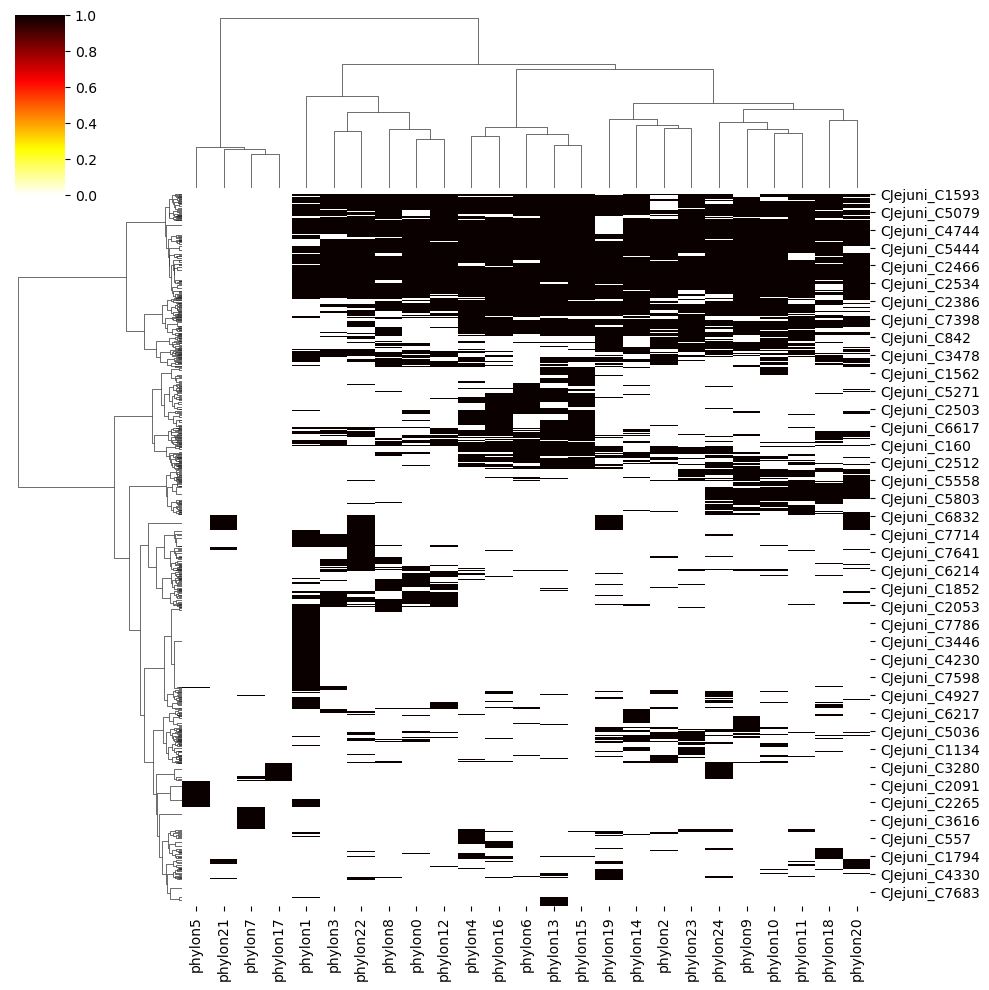

In [14]:
# Grab the clustering order (by Ward's minimum variance)
g = sns.clustermap(
    L_binarized,
    method='ward',
    cmap='hot_r'
);

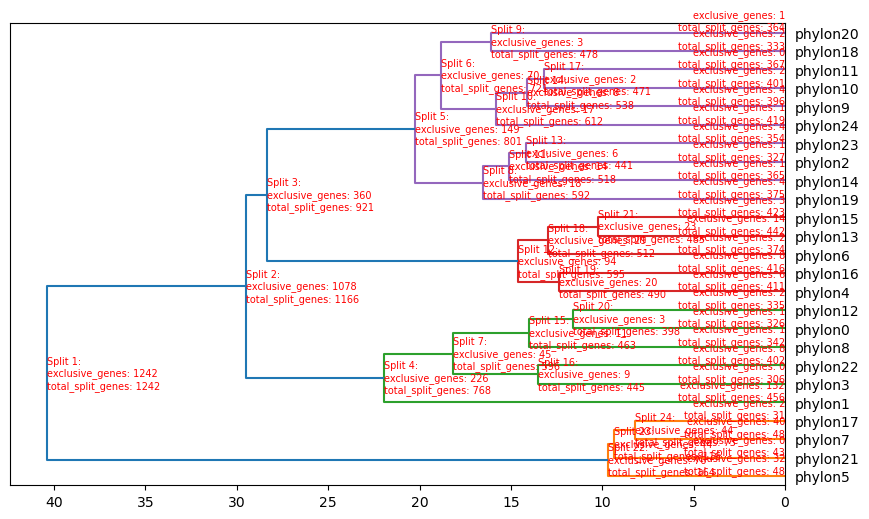

In [15]:
from pyphylon.plotting import generate_phylon_dendrogram
ax, df_stats, split_gene_sets_labeled = generate_phylon_dendrogram(L_binarized, text_offset=0,
                                                    labels = ['exclusive_genes', 'total_split_genes'], orientation = 'left')

In [16]:
df_stats

,ubiquitous_exclusive_genes,exclusive_genes,total_split_genes,total_ubiquitous_genes,split_membership
Split 1,0,1242,1242,0,phylon5;phylon21;phylon7;phylon17;phylon1;phyl...
Split 2,22,1078,1166,22,phylon1;phylon3;phylon22;phylon8;phylon0;phylo...
Split 3,0,360,921,51,phylon4;phylon16;phylon6;phylon13;phylon15;phy...
Split 4,1,226,768,134,phylon1;phylon3;phylon22;phylon8;phylon0;phylon12
Split 5,0,149,801,66,phylon19;phylon14;phylon2;phylon23;phylon24;ph...
Split 6,20,70,721,138,phylon24;phylon9;phylon10;phylon11;phylon18;ph...
Split 7,5,45,596,160,phylon3;phylon22;phylon8;phylon0;phylon12
Split 8,0,18,592,151,phylon19;phylon14;phylon2;phylon23
Split 9,0,3,478,219,phylon18;phylon20
Split 10,3,17,612,225,phylon24;phylon9;phylon10;phylon11
